# 01 -- Transformer baseline

Baseline оставляю простым, но делаю чуть сильнее исходной версии:

`9 values -> Linear(96) -> CLS + positional embedding -> 6 Transformer blocks -> classifier`.

Модель обучается только на чистом train. Epoch выбирается по clean validation macro F1. После этого отдельно проверяю robustness на заранее фиксированных уровнях block corruption.

In [14]:
from pathlib import Path
from time import perf_counter
import json
import os
import platform
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'
FIG = ROOT / 'figures'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = 'cuda'
    ACCELERATOR = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    ACCELERATOR = 'Apple Metal Performance Shaders'
else:
    DEVICE = 'cpu'
    ACCELERATOR = platform.processor() or platform.machine()

compute_config = {
    'device': DEVICE,
    'accelerator': ACCELERATOR,
    'platform': platform.platform(),
    'python': platform.python_version(),
    'torch': torch.__version__,
    'cpu_count': os.cpu_count(),
}
with open(RESULTS / 'compute_config.json', 'w') as f:
    json.dump(compute_config, f, indent=2)

compute_config


{'device': 'mps',
 'accelerator': 'Apple Metal Performance Shaders',
 'platform': 'macOS-26.6.2-arm64-arm-64bit-Mach-O',
 'python': '3.14.7',
 'torch': '2.14.0',
 'cpu_count': 14}

In [15]:
data = np.load(DATA / 'uci_har_raw.npz')
split = np.load(DATA / 'split.npz')

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
train_idx, val_idx = split['train_idx'], split['val_idx']

fit_mean = X_train[train_idx].mean(axis=(0, 2), keepdims=True)
fit_std = X_train[train_idx].std(axis=(0, 2), keepdims=True) + 1e-6
X_train_select = (X_train - fit_mean) / fit_std

BATCH_SIZE = 128

def loader(X, y, idx=None, shuffle=False):
    if idx is not None:
        X, y = X[idx], y[idx]
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = loader(X_train_select, y_train, train_idx, shuffle=True)
val_loader = loader(X_train_select, y_train, val_idx)


In [16]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, channels=9, seq_len=128, classes=6, dim=96, heads=4, depth=6):
        super().__init__()
        self.proj = nn.Linear(channels, dim)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.randn(1, seq_len + 1, dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=dim * 2,
            dropout=0.15,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, classes)

    def forward(self, x):
        x = self.proj(x.transpose(1, 2))
        cls = self.cls.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        x = self.encoder(x)
        return self.head(self.norm(x[:, 0]))


def make_model():
    return TimeSeriesTransformer().to(DEVICE)

model = make_model()
params = sum(p.numel() for p in model.parameters())
print(f'parameters: {params:,}')

parameters: 462,918


/var/folders/34/mhj08xxn2x9gpmpz2jw_v2n80000gn/T/ipykernel_80866/1918167785.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=depth)


In [17]:
def sync():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    elif DEVICE == 'mps':
        torch.mps.synchronize()


def evaluate(model, data_loader):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for x, y in data_loader:
            logits = model(x.to(DEVICE))
            ys.append(y.numpy())
            preds.append(logits.argmax(1).cpu().numpy())
    y = np.concatenate(ys)
    pred = np.concatenate(preds)
    return {
        'accuracy': accuracy_score(y, pred),
        'balanced_accuracy': balanced_accuracy_score(y, pred),
        'macro_f1': f1_score(y, pred, average='macro'),
    }, y, pred

MAX_EPOCHS = 60
PATIENCE = 12
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=5e-5
)

history = []
best_f1 = -1
best_epoch = 1
bad_epochs = 0

sync()
selection_start = perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    losses = []
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    val_metrics, _, _ = evaluate(model, val_loader)
    history.append({
        'epoch': epoch,
        'loss': np.mean(losses),
        'lr': optimizer.param_groups[0]['lr'],
        **val_metrics,
    })
    print(f"{epoch:02d}  loss={np.mean(losses):.4f}  val_f1={val_metrics['macro_f1']:.4f}")

    if val_metrics['macro_f1'] > best_f1:
        best_f1 = val_metrics['macro_f1']
        best_epoch = epoch
        bad_epochs = 0
    else:
        bad_epochs += 1

    scheduler.step()
    if bad_epochs >= PATIENCE:
        break

sync()
selection_time = perf_counter() - selection_start
pd.DataFrame(history).to_csv(RESULTS / '01_transformer_history.csv', index=False)
print('best epoch:', best_epoch)

01  loss=0.8004  val_f1=0.9054
02  loss=0.4359  val_f1=0.9508
03  loss=0.3895  val_f1=0.9713
04  loss=0.3725  val_f1=0.9614
05  loss=0.3643  val_f1=0.9622
06  loss=0.3627  val_f1=0.9620
07  loss=0.3524  val_f1=0.9657
08  loss=0.3488  val_f1=0.9682
09  loss=0.3497  val_f1=0.9551
10  loss=0.3473  val_f1=0.9593
11  loss=0.3399  val_f1=0.9454
12  loss=0.3382  val_f1=0.9697
13  loss=0.3375  val_f1=0.9694
14  loss=0.3356  val_f1=0.9721
15  loss=0.3374  val_f1=0.9615
16  loss=0.3294  val_f1=0.9629
17  loss=0.3210  val_f1=0.9724
18  loss=0.3164  val_f1=0.9662
19  loss=0.3172  val_f1=0.9666
20  loss=0.3036  val_f1=0.9611
21  loss=0.3061  val_f1=0.9678
22  loss=0.3019  val_f1=0.9683
23  loss=0.3045  val_f1=0.9499
24  loss=0.2991  val_f1=0.9717
25  loss=0.2926  val_f1=0.9457
26  loss=0.2987  val_f1=0.9539
27  loss=0.2913  val_f1=0.9677
28  loss=0.2894  val_f1=0.9634
29  loss=0.2824  val_f1=0.9696
best epoch: 17


In [18]:
# После выбора epoch переобучаю тот же baseline на всем official train.
full_mean = X_train.mean(axis=(0, 2), keepdims=True)
full_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
X_train_final = (X_train - full_mean) / full_std
X_test_final = (X_test - full_mean) / full_std

full_train_loader = loader(X_train_final, y_train, shuffle=True)
test_loader = loader(X_test_final, y_test)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
model = make_model()
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=5e-5
)

sync()
t0 = perf_counter()
for _ in range(best_epoch):
    model.train()
    for x, y in full_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
    scheduler.step()
sync()
train_time = perf_counter() - t0

test_metrics, y_true, y_pred = evaluate(model, test_loader)

model.eval()
sync()
t0 = perf_counter()
with torch.no_grad():
    for x, _ in test_loader:
        _ = model(x.to(DEVICE))
sync()
inference_time = perf_counter() - t0
latency_ms = 1000 * inference_time / len(y_test)

baseline = {
    'model': 'Transformer',
    'device': DEVICE,
    'params': int(params),
    'best_epoch': int(best_epoch),
    'selection_time_s': float(selection_time),
    'train_time_s': float(train_time),
    'latency_ms_sample': float(latency_ms),
    **{k: float(v) for k, v in test_metrics.items()},
}

with open(RESULTS / '01_transformer_metrics.json', 'w') as f:
    json.dump(baseline, f, indent=2)

torch.save(model.state_dict(), RESULTS / '01_transformer.pt')
pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).T.to_csv(
    RESULTS / '01_transformer_class_report.csv'
)

baseline

/var/folders/34/mhj08xxn2x9gpmpz2jw_v2n80000gn/T/ipykernel_80866/1918167785.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=depth)


{'model': 'Transformer',
 'device': 'mps',
 'params': 462918,
 'best_epoch': 17,
 'selection_time_s': 114.0084976250073,
 'train_time_s': 78.33336066699121,
 'latency_ms_sample': 0.20254176585803274,
 'accuracy': 0.9148286392941974,
 'balanced_accuracy': 0.9152100387214214,
 'macro_f1': 0.9136717782510245}

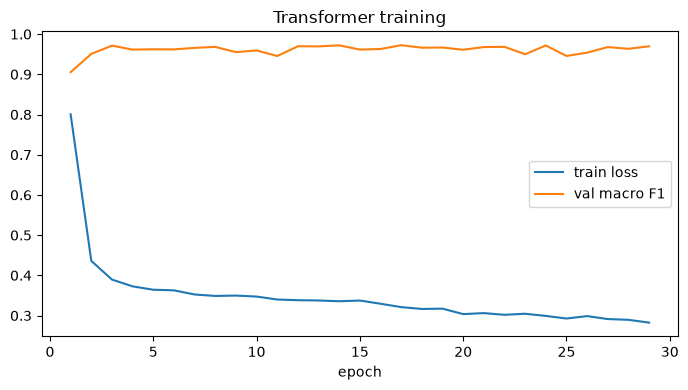

In [19]:
h = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h.epoch, h.loss, label='train loss')
ax.plot(h.epoch, h.macro_f1, label='val macro F1')
ax.set_xlabel('epoch')
ax.legend()
ax.set_title('Transformer training')
plt.tight_layout()
plt.savefig(FIG / '01_transformer_learning.png', dpi=160)
plt.show()


### Что видно по обучению

Лучший validation macro F1 получен на **17-й эпохе: 0.9724**. После этого train loss продолжает в среднем снижаться, а validation F1 колеблется и нового максимума не дает. Поэтому более длинное обучение само по себе здесь не улучшает generalization; `best_epoch` выбирается по validation, а затем модель с нуля обучается на всем official train ровно столько эпох.

На official test итоговый macro F1 заметно ниже -- **0.9137**. Это не противоречие с validation: split сделан по людям, и test содержит полностью других subjects. Разрыв показывает, что для небольшого supervised Transformer межсубъектный перенос существенно сложнее, чем fit на конкретной validation-группе.


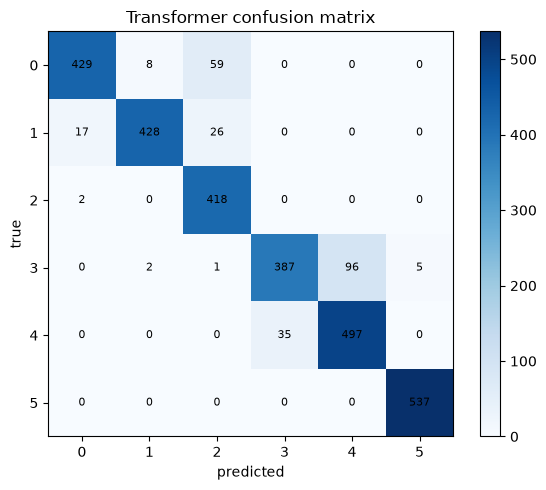

In [20]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('Transformer confusion matrix')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIG / '01_transformer_confusion.png', dpi=160)
plt.show()


### Где baseline ошибается

По class-wise F1 наиболее сложны статические активности: `SITTING` -- **0.8478**, `STANDING` -- **0.8836**. `LAYING`, наоборот, почти насыщен (`0.9954`). Это ожидаемый профиль для HAR: сидение и стояние имеют близкую локальную динамику, поэтому их труднее разделить по короткому окну inertial-сигнала.

Это полезно дальше: если Mantis улучшит именно `SITTING/STANDING`, выигрыш будет связан не только с общим сдвигом accuracy, а с более содержательным представлением трудных классов.


## Robustness stress-test

Теперь baseline не переобучается. Беру уже выбранную clean-модель и порчу только test-вход.

У `4/9` каналов заменяю один непрерывный блок длиной `20%`, `35%` или `50%` окна средним по оставшейся наблюдаемой части канала. Все уровни заданы заранее; test не используется для выбора hyperparameters.

In [21]:
CORRUPTION_LEVELS = [0.0, 0.20, 0.35, 0.50]
CORRUPT_CHANNELS = 4


def block_corrupt(X, fraction, n_channels=CORRUPT_CHANNELS, seed=SEED + 1000):
    Xc = X.copy()
    if fraction == 0:
        return Xc

    rng = np.random.default_rng(seed)
    _, channels, length = Xc.shape
    width = max(1, int(round(length * fraction)))

    for i in range(len(Xc)):
        selected = rng.choice(channels, size=n_channels, replace=False)
        center = int(rng.integers(0, length))
        start = min(max(center - width // 2, 0), length - width)
        observed = np.ones(length, dtype=bool)
        observed[start:start + width] = False

        for ch in selected:
            fill = Xc[i, ch, observed].mean()
            Xc[i, ch, start:start + width] = fill

    return Xc


robust_rows = []
for fraction in CORRUPTION_LEVELS:
    Xc = block_corrupt(X_test, fraction)
    Xc = (Xc - full_mean) / full_std
    m, _, _ = evaluate(model, loader(Xc, y_test))
    robust_rows.append({'corruption': fraction, **m})

transformer_robustness = pd.DataFrame(robust_rows)
transformer_robustness.to_csv(RESULTS / '01_transformer_robustness.csv', index=False)
transformer_robustness

,corruption,accuracy,balanced_accuracy,macro_f1
0,0.00,0.914829,0.915210,0.913672
1,0.20,0.909399,0.909154,0.908001
2,0.35,0.901256,0.900072,0.899438
3,0.50,0.887343,0.884818,0.884819


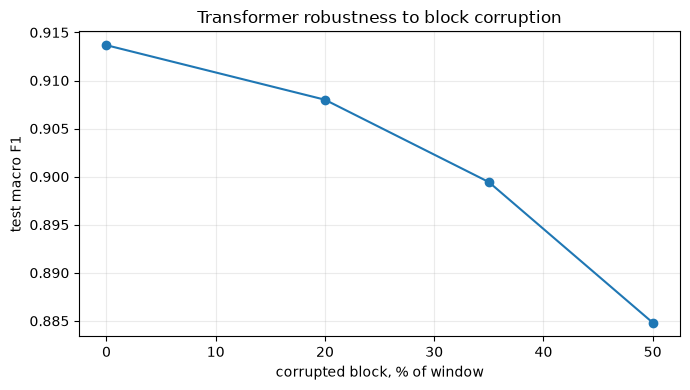

clean F1: 0.9137
50% corruption F1: 0.8848
drop: 0.0289


In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(100 * transformer_robustness.corruption, transformer_robustness.macro_f1, marker='o')
ax.set_xlabel('corrupted block, % of window')
ax.set_ylabel('test macro F1')
ax.set_title('Transformer robustness to block corruption')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG / '01_transformer_robustness.png', dpi=160)
plt.show()

print(f"clean F1: {transformer_robustness.iloc[0].macro_f1:.4f}")
print(f"50% corruption F1: {transformer_robustness.iloc[-1].macro_f1:.4f}")
print(f"drop: {transformer_robustness.iloc[0].macro_f1 - transformer_robustness.iloc[-1].macro_f1:.4f}")

### Robustness baseline

При увеличении поврежденного блока от `0%` до `50%` macro F1 снижается с **0.9137 до 0.8848**, то есть на **0.0289**. Падение плавное: baseline не разваливается даже при сильной порче, но его clean-качество изначально ограничено.

Важно: эта кривая измеряет только устойчивость уже обученной clean-модели. По ней нельзя делать вывод, что Transformer умеет работать с missing values -- он просто оказывается относительно нечувствителен к выбранному способу удаления части сигнала.


### Что здесь проверяется

Это не обучение на «грязных» данных. Модель видела только clean train, поэтому падение качества показывает устойчивость representation к distribution shift. Такой тест полезнее простого усложнения датасета: можно отдельно сравнить clean quality и robustness.

## Baseline

Финальный Transformer: **macro F1 = 0.9137**, accuracy = `0.9148`. Лучший epoch выбирался только по clean validation, после чего модель была заново обучена на всем official train.

Stress-test сохраняется как дополнительная ось сравнения: при `50%` block corruption macro F1 = **0.8848**. Дальше Mantis сравнивается с этим же фиксированным baseline и на clean test, и на тех же заранее заданных corruption levels.
